In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from sklearn.metrics import confusion_matrix, classification_report
import torch


In [28]:
data = pd.read_csv("BreastCancerData (4).csv")

In [29]:
data

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [30]:
data_columns = data.columns
data_columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='str')

In [31]:
len(data_columns)
data.drop(labels=data_columns[32], axis=1, inplace=True)

In [32]:
data.info()
data.isnull().sum().sort_values(ascending=False)

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [33]:
def plot_grid_histo(data, data_columns, n_cols=2, figure_width=15, row_height=4):
  
    feature_cols = [c for c in data_columns if c != "diagnosis"]
    
    n_rows = int(np.ceil(len(feature_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(figure_width, n_rows * row_height))
    axes = axes.flatten()  # easier to index linearly

    for idx, col in enumerate(feature_cols):
        sns.histplot(
            data=data, x=col, hue="diagnosis",
            stat="density", bins=10, kde=True,
            palette=[sns.color_palette()[3], sns.color_palette()[0]],
            element="step", ax=axes[idx]
        )
    plt.tight_layout()
    plt.show()



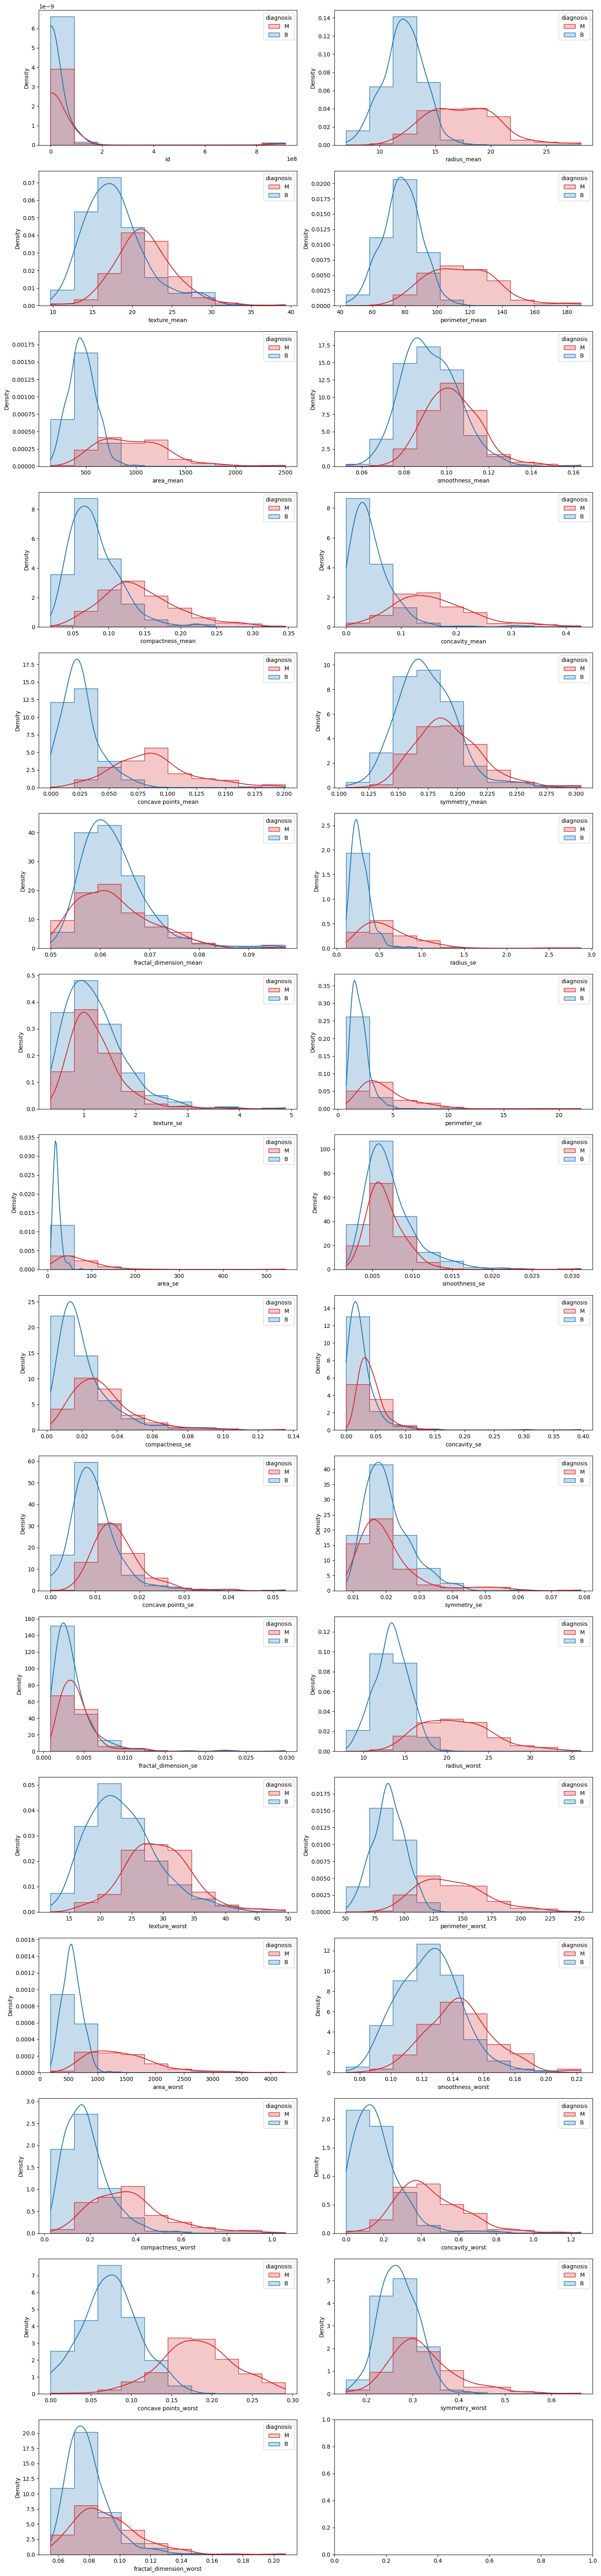

In [34]:
plot_grid_histo(data=data, data_columns=data.columns, n_cols=2)

In [35]:
data_copt =  data.replace(to_replace=['B','M'],value=[0,1],inplace=False)

In [36]:
corr_df = data_copt.corr()
abs_cor_df = abs(corr_df)
abs_cor_df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,1.000000,0.039769,0.074626,0.099770,0.073159,0.096893,0.012968,0.000096,0.050080,0.044158,...,0.082405,0.064720,0.079986,0.107187,0.010338,0.002968,0.023203,0.035174,0.044224,0.029866
diagnosis,0.039769,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560,0.596534,0.696360,0.776614,...,0.776454,0.456903,0.782914,0.733825,0.421465,0.590998,0.659610,0.793566,0.416294,0.323872
radius_mean,0.074626,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.099770,0.415185,0.323782,1.000000,0.329533,0.321086,0.023389,0.236702,0.302418,0.293464,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.073159,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.096893,0.708984,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.012968,0.358560,0.170581,0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.000096,0.596534,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.050080,0.696360,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.044158,0.776614,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661


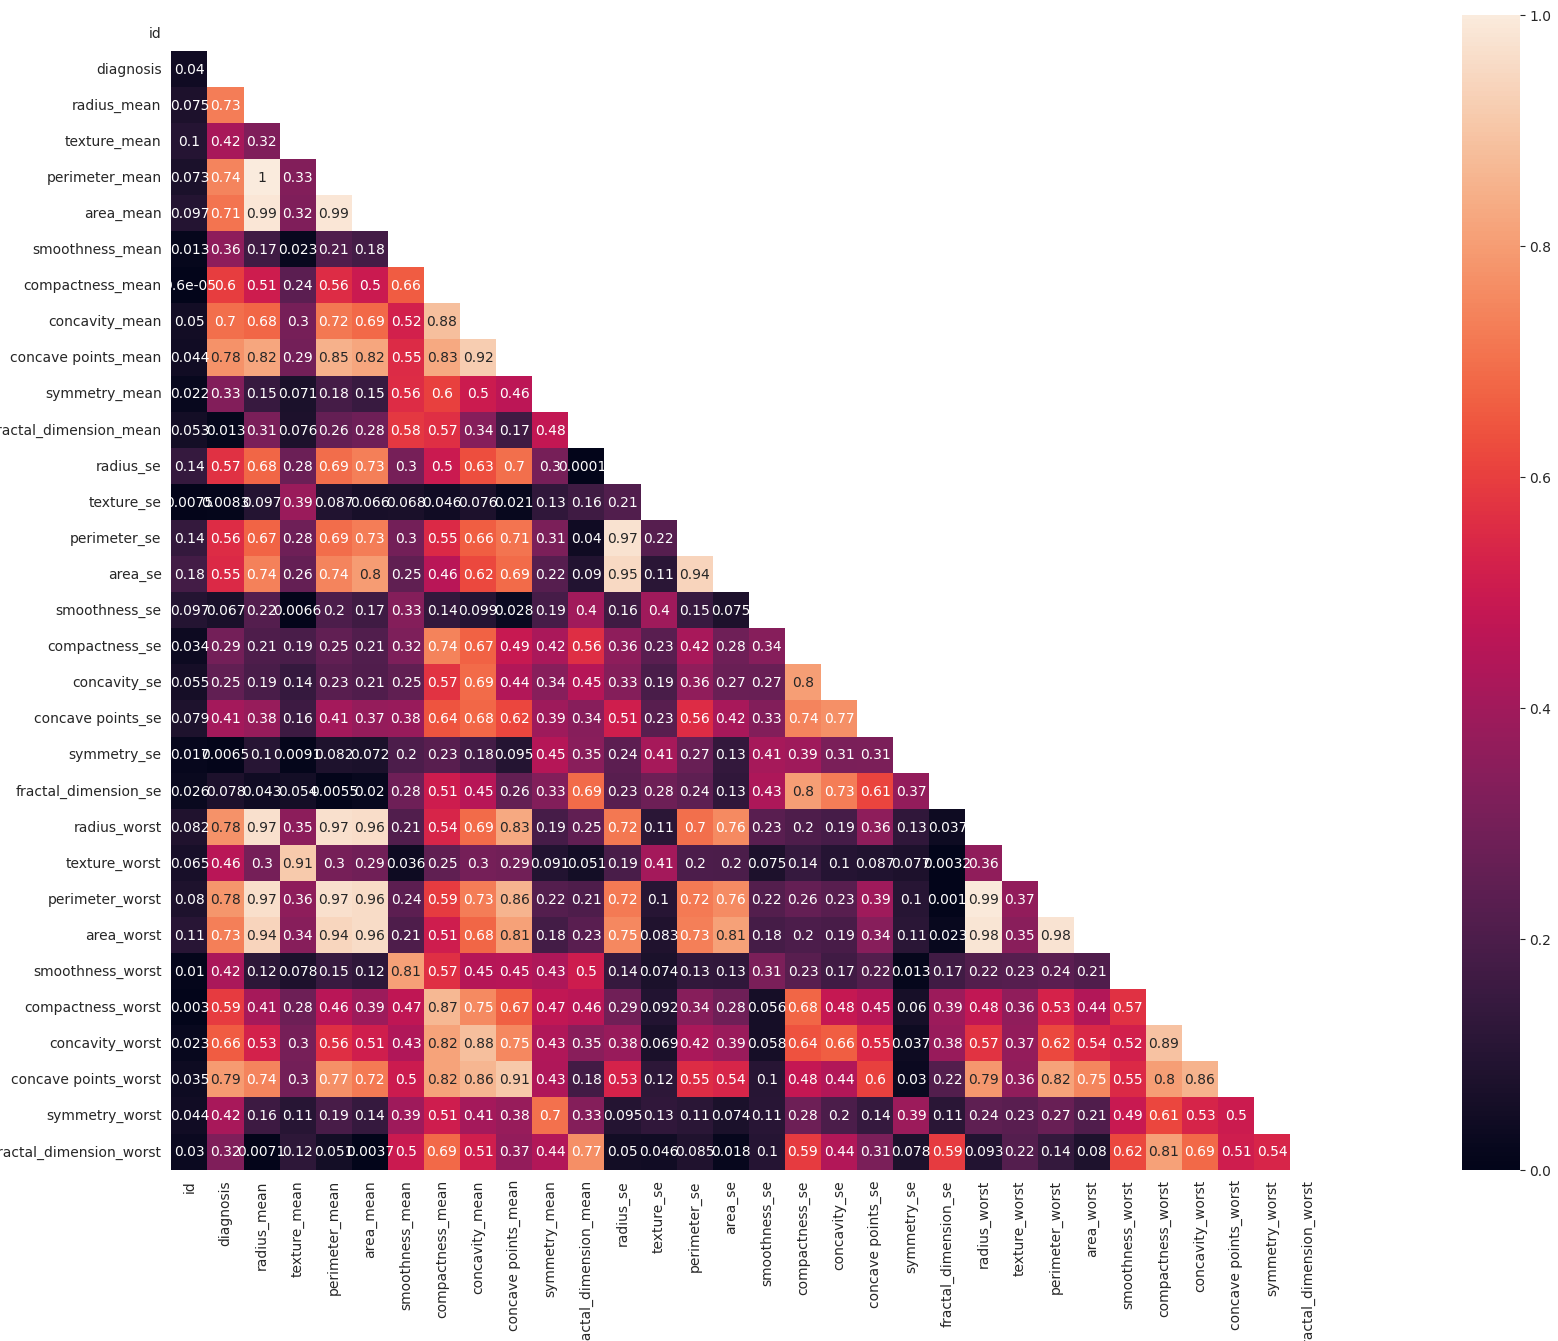

In [37]:
mask = np.zeros_like(abs_cor_df, dtype=bool)
mask[np.triu_indices_from(mask)] = True
with sns.axes_style("white"):
    f, ax = plt.subplots(figsize=(35, 15))
    sns.heatmap(abs_cor_df, vmin=0, vmax=1, mask=mask, square=True, annot=True)

In [38]:
strong_realtionships = pd.Series(abs_cor_df["diagnosis"].nlargest(n=9).iloc[1:])
strong_realtionships

concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
Name: diagnosis, dtype: float64

In [39]:
diagnosis = data_copt["diagnosis"]
data_copt = data_copt[list(strong_realtionships.to_dict().keys())]

In [40]:
data_copt['diagnosis'] = diagnosis
data_copt

,concave points_worst,perimeter_worst,concave points_mean,radius_worst,perimeter_mean,area_worst,radius_mean,area_mean,diagnosis
0,0.2654,184.60,0.14710,25.380,122.80,2019.0,17.99,1001.0,1
1,0.1860,158.80,0.07017,24.990,132.90,1956.0,20.57,1326.0,1
2,0.2430,152.50,0.12790,23.570,130.00,1709.0,19.69,1203.0,1
3,0.2575,98.87,0.10520,14.910,77.58,567.7,11.42,386.1,1
4,0.1625,152.20,0.10430,22.540,135.10,1575.0,20.29,1297.0,1
...,...,...,...,...,...,...,...,...,...
564,0.2216,166.10,0.13890,25.450,142.00,2027.0,21.56,1479.0,1
565,0.1628,155.00,0.09791,23.690,131.20,1731.0,20.13,1261.0,1
566,0.1418,126.70,0.05302,18.980,108.30,1124.0,16.60,858.1,1
567,0.2650,184.60,0.15200,25.740,140.10,1821.0,20.60,1265.0,1


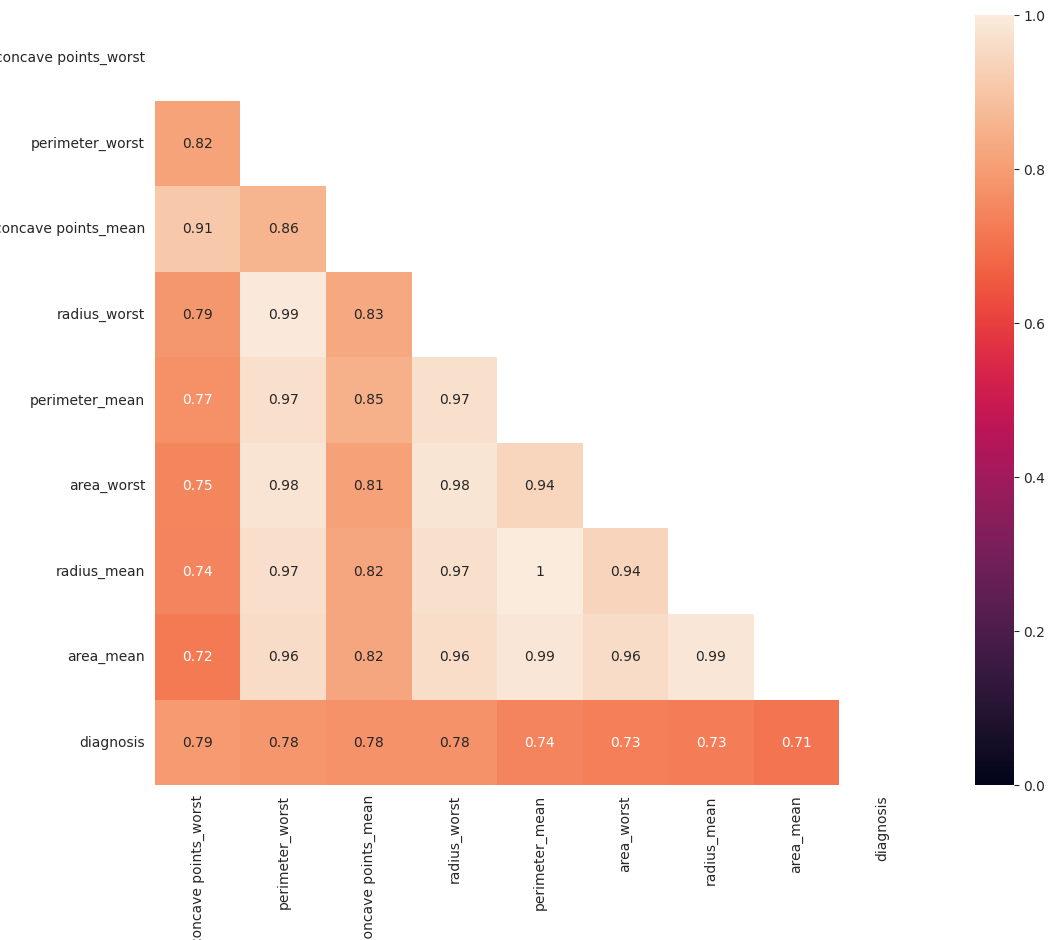

In [41]:
mask = np.zeros_like(data_copt.corr())
mask[np.triu_indices_from(mask)] = True
with sns.axes_style("white"):
    f, ax = plt.subplots(figsize=(13, 10))
    sns.heatmap(data_copt.corr(), vmin=0, vmax=1, mask=mask, square=True, annot=True)

In [42]:
data_copt_cop = np.array(data_copt[list(strong_realtionships.to_dict().keys())].cov())


In [43]:
data_copt_cop


array([[4.32074068e-03, 1.80307085e+00, 2.32144382e-03, 2.50164782e-01,
        1.23184809e+00, 2.79722743e+01, 1.72392739e-01, 1.67017894e+01],
       [1.80307085e+00, 1.12913085e+03, 1.11601611e+00, 1.61387312e+02,
        7.92328208e+02, 1.87028700e+04, 1.14288570e+02, 1.13417898e+04],
       [2.32144382e-03, 1.11601611e+00, 1.50566077e-03, 1.55720694e-01,
        8.02360375e-01, 1.78868809e+01, 1.12475116e-01, 1.12419582e+01],
       [2.50164782e-01, 1.61387312e+02, 1.55720694e-01, 2.33602242e+01,
        1.13858063e+02, 2.70785053e+03, 1.65137495e+01, 1.63752134e+03],
       [1.23184809e+00, 7.92328208e+02, 8.02360375e-01, 1.13858063e+02,
        5.90440480e+02, 1.30261484e+04, 8.54471417e+01, 8.43577235e+03],
       [2.79722743e+01, 1.87028700e+04, 1.78868809e+01, 2.70785053e+03,
        1.30261484e+04, 3.24167385e+05, 1.88822722e+03, 1.92192558e+05],
       [1.72392739e-01, 1.14288570e+02, 1.12475116e-01, 1.65137495e+01,
        8.54471417e+01, 1.88822722e+03, 1.24189201e+01, 1.

In [44]:
data_copt_cop.shape

(8, 8)

In [45]:
data_copt_cop_det = np.linalg.det(data_copt_cop)
data_copt_cop_det

np.float64(114.15727331082711)

In [46]:
data_copt[data_copt['diagnosis'] == 0].shape[0]


357

In [47]:
data_copt[data_copt['diagnosis'] == 1].shape[0]


212

In [48]:
corr_matrix = data_copt.corr()['diagnosis'].abs()

features = (
    abs_cor_df['diagnosis']
    .drop('diagnosis')
    .sort_values(ascending=False)
    .head(8)
    .index
    .tolist()
)


X = data_copt[features].values
y = data_copt['diagnosis'].values


In [49]:
np.random.seed(42)

def manual_train_test_split(X, y, test_size=0.25):
    idx_benign    = np.where(y == 0)[0]
    idx_malignant = np.where(y == 1)[0]

    np.random.shuffle(idx_benign)
    np.random.shuffle(idx_malignant)

    n_test_benign    = int(len(idx_benign)    * test_size)
    n_test_malignant = int(len(idx_malignant) * test_size)

    test_idx_benign    = idx_benign[:n_test_benign]
    train_idx_benign   = idx_benign[n_test_benign:]

    test_idx_malignant  = idx_malignant[:n_test_malignant]
    train_idx_malignant = idx_malignant[n_test_malignant:]

    train_idx = np.concatenate([train_idx_benign, train_idx_malignant])
    test_idx  = np.concatenate([test_idx_benign,  test_idx_malignant])

    np.random.shuffle(train_idx)
    np.random.shuffle(test_idx)

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

# Panggil fungsi
X_train, X_test, y_train, y_test = manual_train_test_split(X, y, test_size=0.25)

print("\nHasil Split Manual:")
print(f"  Train → Benign: {sum(y_train==0)}, Malignant: {sum(y_train==1)}, Total: {len(y_train)}")
print(f"  Test  → Benign: {sum(y_test==0)},  Malignant: {sum(y_test==1)},  Total: {len(y_test)}")


Hasil Split Manual:
  Train → Benign: 268, Malignant: 159, Total: 427
  Test  → Benign: 89,  Malignant: 53,  Total: 142


In [52]:
# ─────────────────────────────────────────────
# PASTIKAN TIPE DATA Y INTEGER
# ─────────────────────────────────────────────
X = data_copt[features].values
y = data_copt['diagnosis'].values.astype(int)  # tambah .astype(int)

print(f"Tipe data y: {y.dtype}")  # harus int32 atau int64

Tipe data y: int64


In [53]:
# Cast dulu sebelum SMOTE
y_train = y_train.astype(int)

# Baru SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("\nSesudah SMOTE:")
print(f"  Train → Benign: {sum(y_train==0)}, Malignant: {sum(y_train==1)}, Total: {len(y_train)}")
print(f"  Test  → Benign: {sum(y_test==0)},  Malignant: {sum(y_test==1)},  Total: {len(y_test)}")

NameError: name 'SMOTE' is not defined

In [54]:
# Kalau isinya string M/B
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(data_copt['diagnosis'].values)  # M=1, B=0

In [55]:
from imblearn.over_sampling import SMOTE

# ─────────────────────────────────────────────
# SPLIT MANUAL DULU (dari kode sebelumnya)
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = manual_train_test_split(X, y, test_size=0.25)

print("Sebelum SMOTE:")
print(f"  Train → Benign: {sum(y_train==0)}, Malignant: {sum(y_train==1)}, Total: {len(y_train)}")
print(f"  Test  → Benign: {sum(y_test==0)},  Malignant: {sum(y_test==1)},  Total: {len(y_test)}")

# ─────────────────────────────────────────────
# SMOTE HANYA DI TRAIN
# ─────────────────────────────────────────────
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("\nSesudah SMOTE:")
print(f"  Train → Benign: {sum(y_train==0)}, Malignant: {sum(y_train==1)}, Total: {len(y_train)}")
print(f"  Test  → Benign: {sum(y_test==0)},  Malignant: {sum(y_test==1)},  Total: {len(y_test)} (tidak berubah)")

Sebelum SMOTE:
  Train → Benign: 268, Malignant: 159, Total: 427
  Test  → Benign: 89,  Malignant: 53,  Total: 142

Sesudah SMOTE:
  Train → Benign: 268, Malignant: 268, Total: 536
  Test  → Benign: 89,  Malignant: 53,  Total: 142 (tidak berubah)


In [64]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler
import numpy as np

# ─────────────────────────────────────────────
# 1. SCALING
# ─────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ─────────────────────────────────────────────
# 2. CONVERT KE TENSOR
# ─────────────────────────────────────────────
X_train_t = torch.FloatTensor(X_train_scaled)
X_test_t  = torch.FloatTensor(X_test_scaled)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
y_test_t  = torch.FloatTensor(y_test).unsqueeze(1)

# ─────────────────────────────────────────────
# FIX 1: WEIGHTED SAMPLER — atasi class imbalance
# ─────────────────────────────────────────────
class_counts  = np.bincount(y_train.astype(int))   # [n_class0, n_class1]
class_weights = 1.0 / class_counts                 # bobot terbalik frekuensi
sample_weights = class_weights[y_train.astype(int)]

sampler = WeightedRandomSampler(
    weights     = torch.FloatTensor(sample_weights),
    num_samples = len(sample_weights),
    replacement = True
)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=32, sampler=sampler)
#                                                  ^^^ ganti shuffle=True dengan sampler

# ─────────────────────────────────────────────
# FIX 2: POS_WEIGHT di BCEWithLogitsLoss
#         (lebih stabil dari BCELoss + Sigmoid manual)
# ─────────────────────────────────────────────
pos_weight = torch.tensor([class_counts[0] / class_counts[1]], dtype=torch.float32)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# ─────────────────────────────────────────────
# 3. ARSITEKTUR ANN — hapus Sigmoid di output
#    karena BCEWithLogitsLoss sudah include Sigmoid
# ─────────────────────────────────────────────
class BreastCancerANN(nn.Module):
    def __init__(self):
        super(BreastCancerANN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(8, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
            # Sigmoid DIHAPUS — sudah ada di BCEWithLogitsLoss
        )

    def forward(self, x):
        return self.network(x)

model = BreastCancerANN()
print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# ─────────────────────────────────────────────
# 4. TRAINING
# ─────────────────────────────────────────────
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

EPOCHS = 100
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(EPOCHS):
    # Training phase
    model.train()
    epoch_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)                      # logits (belum sigmoid)
        loss    = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        preds   = (torch.sigmoid(outputs) >= 0.5).float()  # sigmoid saat prediksi
        correct += (preds == y_batch).sum().item()
        total   += y_batch.size(0)

    train_losses.append(epoch_loss / len(train_loader))
    train_accs.append(correct / total)

    # Validation phase
    model.eval()
    with torch.no_grad():
        val_logits = model(X_test_t)
        val_loss   = criterion(val_logits, y_test_t).item()
        val_pred   = (torch.sigmoid(val_logits) >= 0.5).float()
        val_acc    = (val_pred == y_test_t).float().mean().item()

    val_losses.append(val_loss)
    val_accs.append(val_acc)
    scheduler.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1:3d}/{EPOCHS}] "
              f"Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_accs[-1]:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

# ─────────────────────────────────────────────
# 5. EVALUASI — sigmoid manual karena output logits
# ─────────────────────────────────────────────
model.eval()
with torch.no_grad():
    y_prob = torch.sigmoid(model(X_test_t)).numpy().flatten()  # <-- tambah sigmoid
    y_pred = (y_prob >= 0.5).astype(int)
    y_true = y_test_t.numpy().flatten().astype(int)

BreastCancerANN(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=1, bias=True)
  )
)
Total parameters: 3,393


ImportError: cannot import name 'DeterministicAlgorithmsVariable' from 'torch._dynamo.variables.ctx_manager' (d:\Semester 6\Multimodal\Mulyimod\Lib\site-packages\torch\_dynamo\variables\ctx_manager.py)

In [63]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.11.0+cu130
True
